In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import *
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from numpy import argmax
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from yellowbrick.classifier import ROCAUC, ClassificationReport, PrecisionRecallCurve
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import *
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()
print(faces.DESCR)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/mariakhaidukova/scikit_learn_data
.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with toleran

In [18]:
X = faces.data
y = faces.target

In [12]:
print(f"Размер данных: {faces.data.shape}")
print(f"Количество классов: {len(np.unique(faces.target))}")

Размер данных: (400, 4096)
Количество классов: 40


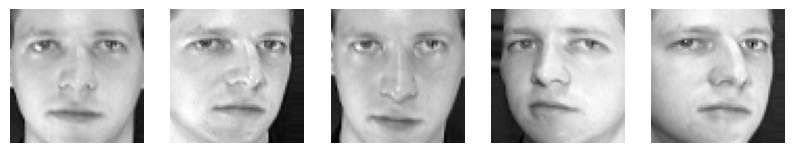

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(faces.images[i], cmap='gray')
    ax.axis('off')
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM (rbf)': SVC(kernel='rbf'),
    'SVM (poly)': SVC(kernel='poly', degree=3),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
}

In [35]:
results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    start = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start
    
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc, train_time, predict_time])

In [37]:
df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Train Time', 'Predict Time'])
print("\n" + df.sort_values('Accuracy', ascending=False).to_string())


                 Model  Accuracy  Train Time  Predict Time
2           SVM (poly)    0.9750    0.036905      0.005326
0  Logistic Regression    0.9625    2.097258      0.000680
1            SVM (rbf)    0.9250    0.048257      0.030792
4                  MLP    0.8875    2.600456      0.000278
3                  KNN    0.8625    0.000466      0.016539


In [38]:
import warnings
warnings.filterwarnings('ignore')

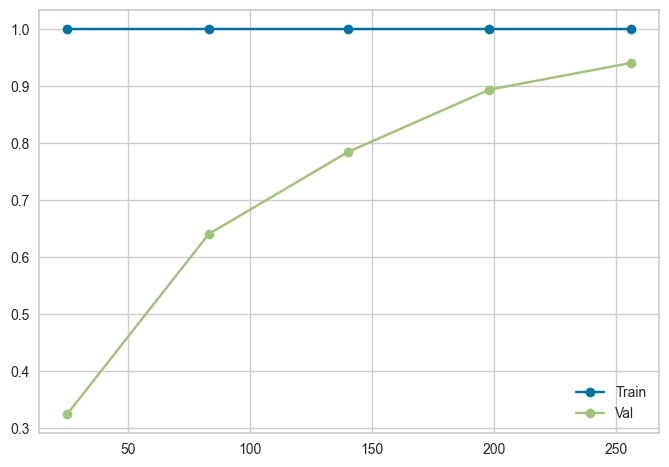

In [39]:
train_sizes, train_scores, test_scores = learning_curve(
    SVC(kernel='poly', degree=3), X_train, y_train, train_sizes=np.linspace(0.1, 1, 5)
)

plt.plot(train_sizes, train_scores.mean(1), 'o-', label='Train')
plt.plot(train_sizes, test_scores.mean(1), 'o-', label='Val')
plt.legend()
plt.show()